In [385]:
from aPythonPack import * #pip install git+https://github.com/sebPV/aPythonPack.git
import aPythonPack.LatexConversions as lc
import scipy as sc
import pandas as pd
import os


In [386]:
def norm(arr):
    out = []
    for i in arr:
        out.append(i.nominal_value)
    return out

In [387]:
from uncertainties import ufloat

# Data imoprt

In [ ]:
fors = []
# pd.read_csv("Data/20260324-090928_Wheel.csv")
# for i in os.listdir('Data'):
for i in os.listdir('Data'):
    fors.append({'data':pd.read_csv("Data/"+i),'file':i})



for i in fors:
    time =[]
    pos = []
    for j in range(len(i['data'][' time'])):
        time.append(ufloat(i['data'][' time'][j],1/200))
        pos.append(ufloat(i['data'][' cal[0]'][j],0.5e-3))
    
    dt = []    
    ds = []
    for j in range(len(time)-1):
        dt.append(time[j+1] -time[j])
        ds.append(pos[j+1] -pos[j])
    ds = np.array(ds)
    dt = np.array(dt)

    vel = ds/dt
    vel = vel*2
    dv = []
    for j in range(len(vel)-1):
        dv.append(vel[j+1] -vel[j])
    acc = dv/(dt[:-1])


    # print(time)
    i['t'] = time[:-2]
    i['s'] = pos[:-2]
    i['v'] = vel[:-1]
    i['a'] = acc


    std_dev = np.std(norm(acc))
    mean = np.mean(acc)
    std_mean = std_dev/np.sqrt(len(acc))
    i['a_mean'] = ufloat((sum(acc)/len(acc)).nominal_value,std_mean)
    print(i['a_mean'].nominal_value-np.average(i['data'][' cal[2]']))

[0.01+/-0.007071067811865475 0.009999999999999998+/-0.007071067811865475
 0.010000000000000002+/-0.007071067811865475
 0.010000000000000002+/-0.007071067811865475
 0.009999999999999995+/-0.007071067811865475
 0.010000000000000009+/-0.007071067811865475
 0.009999999999999995+/-0.007071067811865475
 0.009999999999999995+/-0.007071067811865475
 0.010000000000000009+/-0.007071067811865475
 0.009999999999999995+/-0.007071067811865475
 0.009999999999999995+/-0.007071067811865475
 0.010000000000000009+/-0.007071067811865475
 0.010000000000000009+/-0.007071067811865475
 0.009999999999999981+/-0.007071067811865475
 0.010000000000000009+/-0.007071067811865475
 0.010000000000000009+/-0.007071067811865475
 0.009999999999999981+/-0.007071067811865475
 0.010000000000000009+/-0.007071067811865475
 0.010000000000000009+/-0.007071067811865475
 0.009999999999999981+/-0.007071067811865475
 0.010000000000000009+/-0.007071067811865475
 0.010000000000000009+/-0.007071067811865475
 0.009999999999999981+/-0.0

In [389]:
sum([ufloat(1,1),ufloat(1,1),ufloat(1,1)])/3

1.0+/-0.5773502691896257

In [390]:
acc = acc[:-4]
print(sum(acc)/len(acc))
std_dev = np.std(norm(acc))
mean = np.mean(acc)
std_mean = std_dev/np.sqrt(len(acc))
print(std_mean)
# plt.plot(norm(time[:-2]),norm(acc))
# plt.show()
# plt.plot(norm(time),norm(pos))

2.7+/-2.9
1.0000256838979944


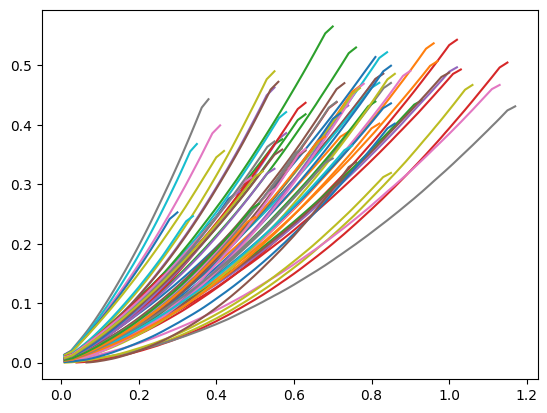

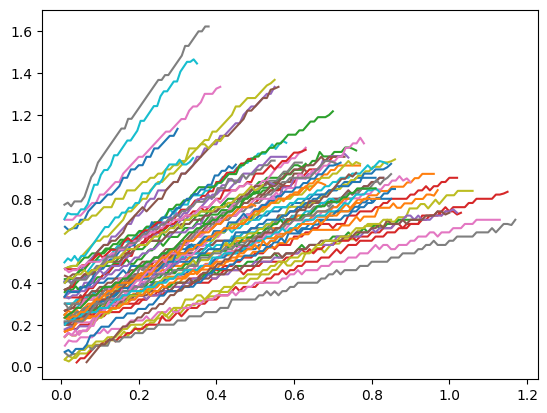

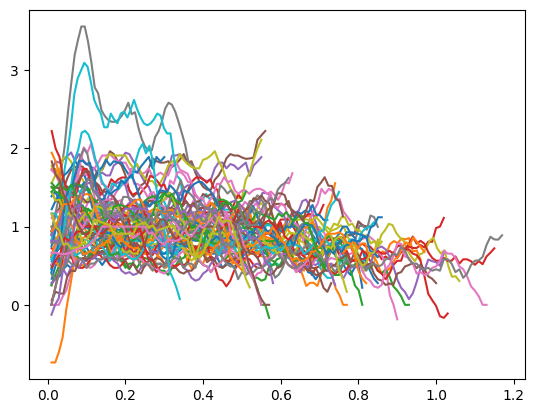

In [391]:
for i in range(3):
    for j in fors:
        plt.plot(j['data'][' time'],j['data'][' cal['+str(i)+']'])
    plt.show()

In [392]:
# PI1,PI2 = [],[]

# for i in fors:
#     t = i['data'][' time'][len(i['data'][' time'])-1]
#     s = i['data'][' cal[0]'][len(i['data'][' time'])-1]
#     v = i['data'][' cal[1]'][1]

#     a = np.average(i['data'][' cal[2]'])
#     i['PI1'] = s/(v*t)
#     i['PI2'] = t * a/(v)
#     PI1.append(i['PI1'])
#     PI2.append(i['PI2'])


In [393]:
PI1,PI2 = [],[]
import math
for i in fors:
    t = i['t'][len(i['t'])-1]
    v = i['v'][0]
    a = i['a_mean']
    s = i['s'][len(i['t'])-1]

    i['PI1'] = s/(v*t)
    i['PI2'] = t * a/(v)
    PI1.append(i['PI1'])
    PI2.append(i['PI2'])


In [394]:
def f(x,a,b):
    return a*x +b

[0.4931648 0.949288 ] [[ 5.12381538e-05 -1.60406323e-04]
 [-1.60406323e-04  1.11797976e-03]]


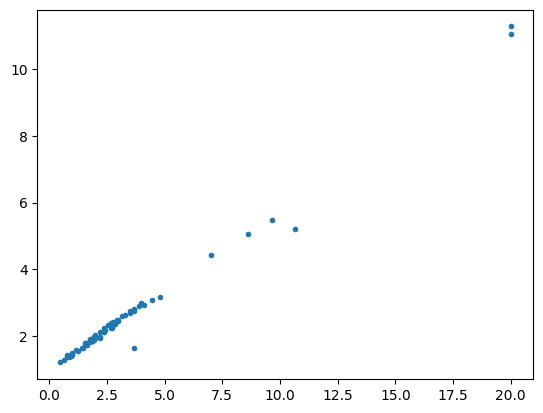

In [395]:
from scipy.optimize import curve_fit
param,cov = curve_fit(f,norm(PI2),norm(PI1))
print(param,cov)
plt.plot(norm(PI2),norm(PI1),'.')
    # plt.show()

In [402]:
plot = lc.tikzPlot(xlabel='\\Pi_2',ylabel='\\Pi_1')
plot.addPlot(norm(PI2),norm(PI1),legend='Data',line='o')
plot.addPlot(norm(PI2),f(np.array([min(norm(PI2)),max(norm(PI2))]),param[0],param[1]),legend='$\\Pi_1 \\cdot'+ str(round(param[0],3))+'+'+str(round(param[1],3))+'$',line='--')
# plot.printPlot()
plot.writePLot('plots/piplot')

In [397]:
from scipy import odr

In [398]:
# Create data object with BOTH uncertainties




data = odr.RealData(x_data, y_data, sx=x_err, sy=y_err)

# Create ODR model
odr_model = odr.Model(model)

# Run regression
odr_fit = odr.ODR(data, odr_model, beta0=[1., 0.])
output = odr_fit.run()

# Results
a, b = output.beta
a_err, b_err = output.sd_beta

print(f"a = {a:.2f} +/- {a_err:.2f}")
print(f"b = {b:.2f} +/- {b_err:.2f}")

NameError: name 'x_data' is not defined